In [1]:
import pandas as pd

events = pd.read_csv("events_cleaned.csv")

weights = {
    "Views": 1,
    "addtocart": 3,
    "transactions": 5,
}

events["interaction_score"] = events["event"].map(weights)
events.head()

,timestamp,visitorid,event,itemid,transactionid,interaction_score
0,1433221332117,257597,view,355908,NaN,NaN
1,1433224214164,992329,view,248676,NaN,NaN
2,1433221999827,111016,view,318965,NaN,NaN
3,1433221955914,483717,view,253185,NaN,NaN
4,1433221337106,951259,view,367447,NaN,NaN


In [2]:
top_users = events["visitorid"].value_counts().head(600).index
top_items = events["itemid"].value_counts().head(300).index

filtered_events = events[
    events["visitorid"].isin(top_users) &
    events["itemid"].isin(top_items)
]


In [3]:
user_item_matrix = filtered_events.pivot_table(
    index ="visitorid",
    columns = "itemid",
    values = "interaction_score",
    aggfunc = "sum",
    fill_value =0
)

print(user_item_matrix.shape)

(414, 267)


In [4]:
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(user_item_matrix)

user_similarity.shape

(414, 414)

In [5]:
import pandas as pd

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

user_similarity_df.head()

visitorid,1879,2194,6699,9535,12579,17676,21395,24757,33604,38015,...,1380669,1381830,1385073,1386940,1391782,1391871,1392946,1394708,1398811,1403769
visitorid,,,,,,,,,,,,,,,,,,,,,
1879,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2194,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6699,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9535,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12579,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
user_id = user_item_matrix.index[0]

similar_users = user_similarity_df[user_id].sort_values(ascending=False)

similar_users.head()

visitorid
1403769    0.0
1879       0.0
2194       0.0
6699       0.0
9535       0.0
Name: 1879, dtype: float64

In [7]:
def recommend_items(user_id, top_n = 5):
    
    similar_users = user_similarity_df[user_id].sort_values(
        ascending=False
    )[1:6] 
    
    recommend_items = []
    
    for similar_users in similar_users.index:
        
        items = user_item_matrix.loc[similar_users]
        
        items = items[items>0].index.tolist()
        
        recommend_items.extend(items)
        
        recommend_items = list(set(recommend_items))
        
        return recommend_items[:top_n]

In [8]:
user_id = user_item_matrix.index[0]

recommend_items(user_id)

[]

In [9]:
user_item_matrix.loc[user_id]
[user_item_matrix.loc[user_id]>0]

[itemid
 546       False
 869       False
 4001      False
 5411      False
 5470      False
           ...  
 459475    False
 460133    False
 460188    False
 461686    False
 464731    False
 Name: 1879, Length: 267, dtype: bool]

In [10]:
active_user = user_item_matrix.sum(axis=1).idxmax()

recommend_items(active_user)

[546, 176162, 320130, 338660, 204057]

In [17]:
recommended = recommend_items(active_user)

print("Recommended Items:")
for item in recommended:
    print(item)

Recommended Items:
546
176162
320130
338660
204057


In [18]:
recommendation_df = pd.DataFrame({
    "recommend_items_id":recommended
})

recommendation_df

,recommend_items_id
0,546
1,176162
2,320130
3,338660
4,204057


In [19]:
recommendation_df.to_csv(
    "recommendatio_items.csv",index=False
)

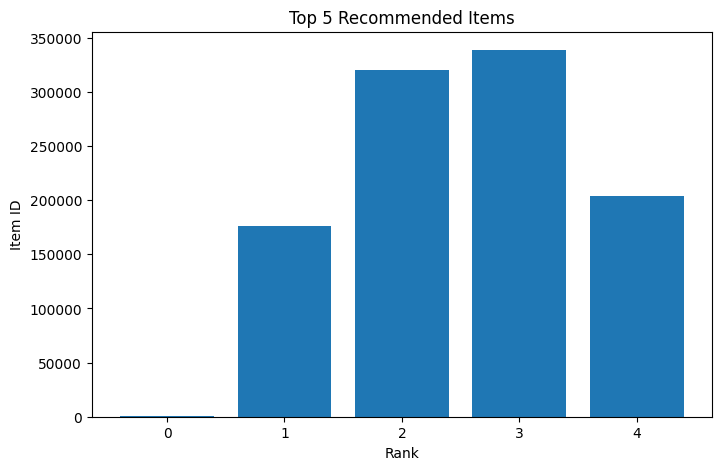

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(
    range(len(recommended)),recommended)

plt.title("Top 5 Recommended Items")
plt.xlabel("Rank")
plt.ylabel("Item ID")
plt.savefig("top_5_recommended_items.png")
plt.show()

In [21]:
model_comparison = pd.DataFrame({
    "Model":["Decision Tree","Random Forest","XGBoost"],"Accuracy":[0.977,0.98,0.98]
})

model_comparison

,Model,Accuracy
0,Decision Tree,0.977
1,Random Forest,0.980
2,XGBoost,0.980


In [22]:
model_comparison.to_csv("model_comparison.csv",index=False)